# 01 — The Synthetic Cohort: What Underwriting Data Looks Like

We generate **GDPR-safe synthetic patients** across four markets — **DE, ES, FR, INT** — with realistic data-quality variance baked in.

The point is not to create a data-cleaning exercise. The variance in completeness, consistency, and recency across markets is a **structural feature** of different healthcare systems: German statutory-health-insurance records look different from international broker submissions, and any downstream model must cope with that gap.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from medrisk.data.synthetic import generate_cohort, cohort_to_dataframe
from medrisk.validation.data_quality import compute_dqs

sns.set_theme(style="whitegrid")
%matplotlib inline

## Generate the synthetic cohort

We create **500 patients per market** (2 000 total) with a fixed seed for reproducibility. Each patient carries demographics, diagnoses, lab results, and medication records drawn from market-specific distributions.

In [2]:
cohort = generate_cohort(n_per_market=500, seed=42)
df = cohort_to_dataframe(cohort)
print(f"Cohort: {len(df)} patients across {df['market'].nunique()} markets")
df.head()

Cohort: 2000 patients across 4 markets


,patient_id,market,age,sex,bmi,smoking_status,n_diagnoses,n_labs,n_medications,follow_up_years,...,med_simvastatin,med_atorvastatin,med_asa,med_rivaroxaban,med_metformin,med_donepezil,med_rivastigmine,med_galantamine,med_memantine,gt_n_conditions
0,7f79b08c-4bba-4431-ad45-e2d1e27179a9,DE,56,F,30.3,former,4,13,1,8.49,...,True,False,False,False,False,False,False,False,False,4
1,75da4374-bbaa-439d-97cd-bf9670394198,DE,27,M,28.7,former,4,13,1,8.44,...,True,False,False,False,False,False,False,False,False,4
2,49c30255-841a-46f3-9922-c1642ce3e58a,DE,52,F,24.1,never,1,14,0,3.23,...,False,False,False,False,False,False,False,False,False,1
3,7577fc8b-0d97-441a-84ab-2a4aaa051003,DE,56,M,17.7,never,1,12,1,6.55,...,False,False,False,False,False,False,False,False,False,1
4,21f7f751-e2ab-4c50-ab0c-b9166cd66e94,DE,32,M,26.8,never,2,12,0,2.40,...,False,False,False,False,False,False,False,False,False,2


## Demographic distributions vary across markets

Age, BMI, comorbidity burden (Charlson index), and diagnostic breadth differ by market — reflecting real-world variation in insured populations and coding practices.

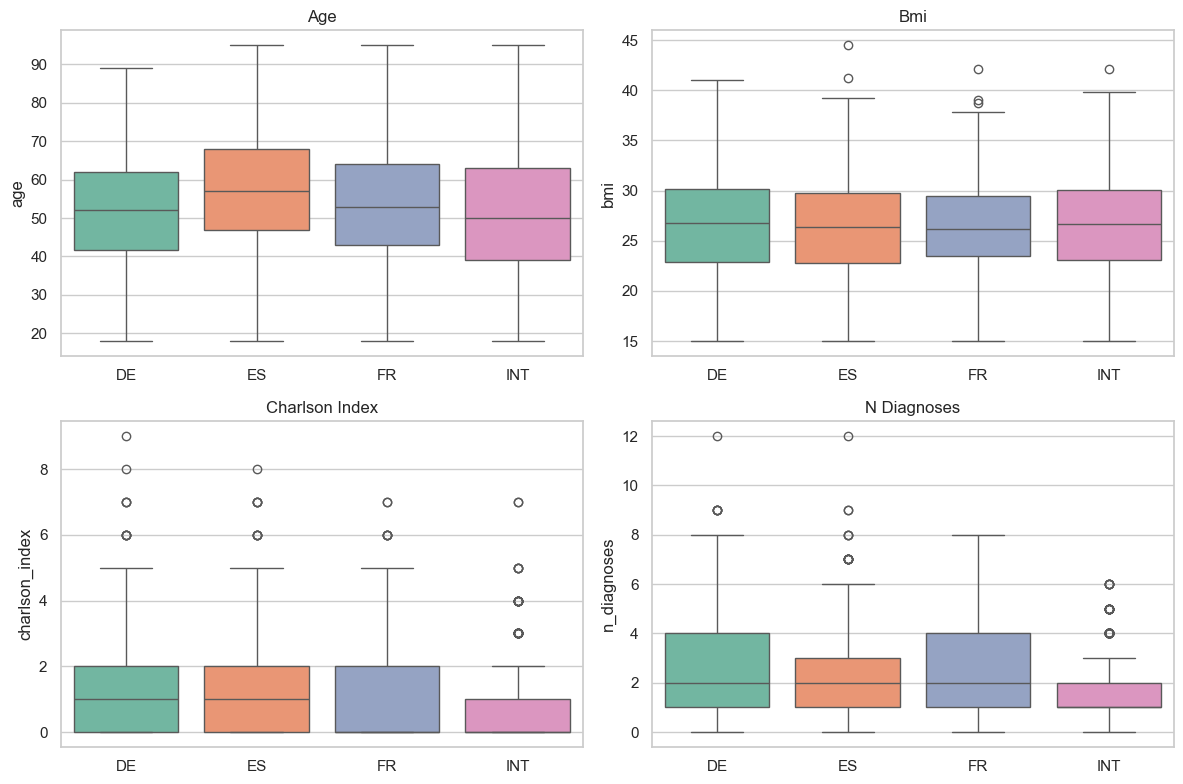

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, ["age", "bmi", "charlson_index", "n_diagnoses"]):
    sns.boxplot(data=df, x="market", y=col, ax=ax, palette="Set2")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

## Data completeness differs structurally across markets

The number of diagnoses, lab results, and medications available per patient is not random — it reflects how thoroughly each healthcare system records and transmits clinical data to insurers.

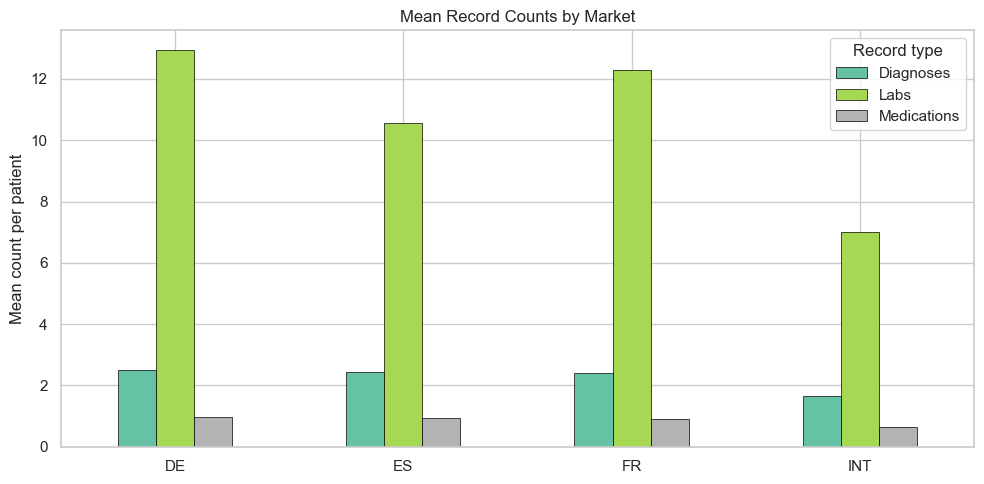

        n_diagnoses  n_labs  n_medications
market                                    
DE              2.5    12.9            1.0
ES              2.4    10.5            0.9
FR              2.4    12.3            0.9
INT             1.6     7.0            0.6


In [4]:
completeness_cols = ["n_diagnoses", "n_labs", "n_medications"]
market_means = df.groupby("market")[completeness_cols].mean()

fig, ax = plt.subplots(figsize=(10, 5))
market_means.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="black", linewidth=0.5)
ax.set_title("Mean Record Counts by Market")
ax.set_ylabel("Mean count per patient")
ax.set_xlabel("")
ax.legend(title="Record type", labels=["Diagnoses", "Labs", "Medications"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(market_means.round(1).to_string())

## The Data Quality Score quantifies how much we should trust model inputs

The **DQS** is a composite score (0 -- 1) built from three sub-scores:
- **Completeness** — are the expected fields present?
- **Consistency** — do the values make clinical sense together?
- **Recency** — how current is the information?

Each patient is assigned a tier: **sufficient** (>= 0.80), **adequate** (>= 0.60), or **insufficient** (< 0.60).

In [5]:
dqs_results = [compute_dqs(p) for p in cohort]
df["dqs"] = [r.dqs for r in dqs_results]
df["dqs_tier"] = [r.tier for r in dqs_results]
df["dqs_completeness"] = [r.completeness for r in dqs_results]
df["dqs_consistency"] = [r.consistency for r in dqs_results]
df["dqs_recency"] = [r.recency for r in dqs_results]

print(f"DQS range: {df['dqs'].min():.3f} — {df['dqs'].max():.3f}")
print(f"Mean DQS:  {df['dqs'].mean():.3f}")
df[["patient_id", "market", "dqs", "dqs_tier", "dqs_completeness", "dqs_consistency", "dqs_recency"]].head(10)

DQS range: 0.232 — 0.827
Mean DQS:  0.672


,patient_id,market,dqs,dqs_tier,dqs_completeness,dqs_consistency,dqs_recency
0,7f79b08c-4bba-4431-ad45-e2d1e27179a9,DE,0.7437,caution,0.575,1.0,0.6550
1,75da4374-bbaa-439d-97cd-bf9670394198,DE,0.7339,caution,0.575,1.0,0.6156
2,49c30255-841a-46f3-9922-c1642ce3e58a,DE,0.7045,caution,0.500,1.0,0.6178
3,7577fc8b-0d97-441a-84ab-2a4aaa051003,DE,0.6973,caution,0.475,1.0,0.6291
4,21f7f751-e2ab-4c50-ab0c-b9166cd66e94,DE,0.6916,caution,0.475,1.0,0.6064
5,2242bc52-8149-4813-93b4-de5c949e7abd,DE,0.7435,caution,0.600,1.0,0.6142
6,8f79e184-8ecd-4e86-a55e-fa58909d41ca,DE,0.6834,caution,0.450,1.0,0.6135
7,4c993074-b7fe-4390-a5d2-65bc248477dc,DE,0.7337,caution,0.525,1.0,0.6949
8,32090b29-36d2-40d5-80e8-0c1c74ead159,DE,0.7944,caution,0.725,1.0,0.6177
9,69771789-0e9c-4724-b64c-c7d51c92c1f4,DE,0.6966,caution,0.500,1.0,0.5862


## DQS distributions reveal the data quality gradient

The violin plot below shows how the composite DQS is distributed within each market. The dashed horizontal lines mark the tier boundaries at **0.60** (adequate) and **0.80** (sufficient).

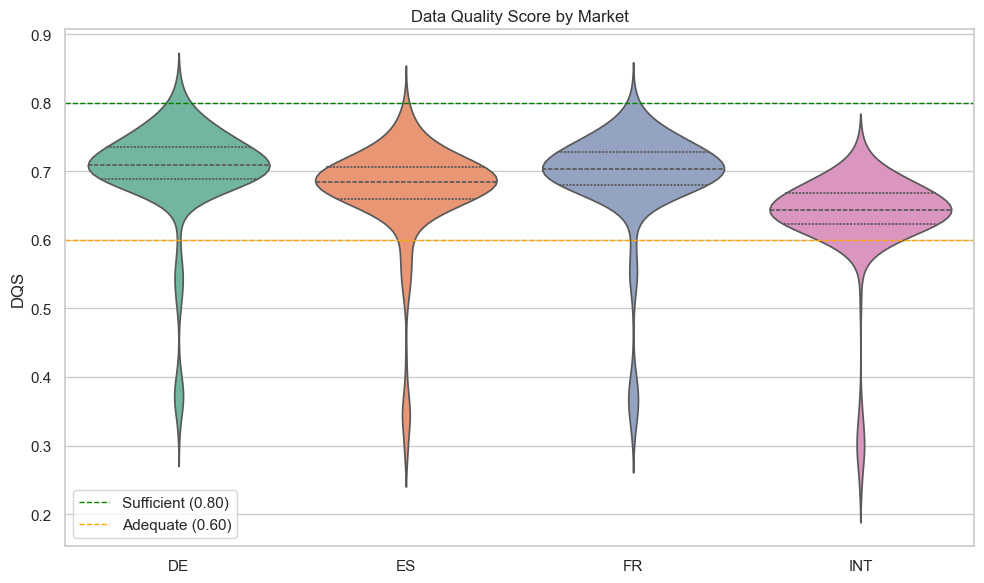

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x="market", y="dqs", palette="Set2", inner="quartile", ax=ax)
ax.axhline(0.80, color="green", linestyle="--", linewidth=1, label="Sufficient (0.80)")
ax.axhline(0.60, color="orange", linestyle="--", linewidth=1, label="Adequate (0.60)")
ax.set_title("Data Quality Score by Market")
ax.set_ylabel("DQS")
ax.set_xlabel("")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [7]:
tier_counts = pd.crosstab(df["market"], df["dqs_tier"])
# Reorder columns for readability
tier_order = ["sufficient", "adequate", "insufficient"]
tier_counts = tier_counts.reindex(columns=[c for c in tier_order if c in tier_counts.columns])
print(tier_counts.to_string())

dqs_tier  adequate  insufficient
market                          
DE               7            36
ES               1            46
FR               2            40
INT              0            52


## Key finding

The **INT** cohort has systematically lower DQS. DE patients are mostly "adequate", INT patients are mostly "insufficient" or "caution". **This is not a data cleaning problem** — it reflects structural differences in healthcare data infrastructure across markets.

Any model trained on this data will face a fundamental challenge: **it receives less information for the patients where getting it right matters most.**

In [8]:
df.to_parquet("../data/cohort.parquet", index=False)
print(f"Saved {len(df)} patients to data/cohort.parquet")

Saved 2000 patients to data/cohort.parquet
